In [1]:
import subprocess, sys, os

def run(cmd):
    print(f">>> {cmd}")
    subprocess.run(cmd, shell=True, check=True)

# Install PyTorch (CUDA 12.x for RTX 5080)
run("pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q")

# Install core dependencies
run('pip install "transformers==4.37.2" "accelerate>=0.25.0" "peft>=0.6.0" "bitsandbytes>=0.41.0" -q')
run("pip install datasets pillow tqdm scikit-learn sentencepiece protobuf -q")


# Clone LLaVA (using Python since Git is not installed)
import urllib.request
import zipfile

if not os.path.exists("LLaVA"):
    print(">>> Downloading LLaVA repository...")
    urllib.request.urlretrieve("https://github.com/haotian-liu/LLaVA/archive/refs/heads/main.zip", "LLaVA.zip")
    print(">>> Extracting...")
    with zipfile.ZipFile("LLaVA.zip", 'r') as zip_ref:
        zip_ref.extractall()
    os.rename("LLaVA-main", "LLaVA")
    os.remove("LLaVA.zip")

    
# Install LLaVA
run("cd LLaVA && pip install -e . -q")

# Optional: flash attention (skip if fails)
try:
    run("pip install flash-attn --no-build-isolation -q")
except:
    print("Flash-attn not available â€” OK, continuing without it")

print("\n All dependencies installed!")



>>> pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 -q
>>> pip install "transformers==4.37.2" "accelerate>=0.25.0" "peft>=0.6.0" "bitsandbytes>=0.41.0" -q
>>> pip install datasets pillow tqdm scikit-learn sentencepiece protobuf -q
>>> Downloading LLaVA repository...
>>> Extracting...
>>> cd LLaVA && pip install -e . -q
>>> pip install flash-attn --no-build-isolation -q
Flash-attn not available â€” OK, continuing without it

 All dependencies installed!


In [3]:
import subprocess, sys

# This installs into the EXACT Python environment the kernel is using
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/cu128",
    "--force-reinstall", "--no-deps"
], check=True)

print("Done! Now restart the kernel.")


Done! Now restart the kernel.


In [1]:
import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    # FIXED: total_mem -> total_memory
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {name}")
    print(f"VRAM: {vram:.1f} GB")
    if vram < 15:
        print("  Less than 15GB â€” will use conservative settings")
    else:
        print("Sufficient VRAM for 4-bit QLoRA training")
else:
    print(" No GPU detected! This notebook requires a GPU.")



GPU: NVIDIA GeForce RTX 5080
VRAM: 17.1 GB
Sufficient VRAM for 4-bit QLoRA training


In [2]:
import subprocess

# Check GPU driver
r = subprocess.run("nvidia-smi", shell=True, capture_output=True, text=True)
print("=== nvidia-smi ===")
print(r.stdout if r.stdout else "NOT FOUND: " + r.stderr)

# Check PyTorch
import torch
print("\n=== PyTorch ===")
print("Version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

# Check which Python/env
import sys
print("\n=== Python ===")
print("Executable:", sys.executable)


=== nvidia-smi ===
Sat May  9 10:07:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5080      WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   36C    P8             16W /  360W |       0MiB /  16303MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------

In [2]:

import json
import os
from datasets import load_dataset
from tqdm.notebook import tqdm

# CONFIG
DATA_DIR = "data/scienceqa"
MAX_TRAIN = None    # None = all image samples; set 3000 for faster training
MAX_TEST = 1000
MAX_VAL = 500

# Create directories
for split in ["train", "validation", "test"]:
    os.makedirs(f"{DATA_DIR}/{split}/images", exist_ok=True)

# Download
print("Downloading ScienceQA dataset...")
ds = load_dataset("derek-thomas/ScienceQA")
print(f"  Train: {len(ds['train'])} | Val: {len(ds['validation'])} | Test: {len(ds['test'])}")

def convert_split(split_name, max_samples=None):
    split = ds[split_name]
    img_dir = f"{DATA_DIR}/{split_name}/images"
    conversations = []
    skipped = 0
    
    for idx, item in enumerate(tqdm(split, desc=split_name)):
        # Skip non-image questions
        if item["image"] is None:
            skipped += 1
            continue
        
        # Save image
        img_file = f"{idx:06d}.png"
        img_path = f"{img_dir}/{img_file}"
        rel_path = f"{DATA_DIR}/{split_name}/images/{img_file}"
        
        if not os.path.exists(img_path):
            try:
                item["image"].save(img_path)
            except:
                skipped += 1
                continue
        
        # Build question
        question = item["question"]
        choices = item["choices"]
        answer_idx = item["answer"]
        choice_str = "\n".join([f"({chr(65+i)}) {c}" for i, c in enumerate(choices)])
        
        parts = []
        hint = item.get("hint", "")
        if hint and hint.strip():
            parts.append(f"Context: {hint.strip()[:300]}")
        
        lecture = item.get("lecture", "")
        if lecture and lecture.strip():
            parts.append(f"Background: {lecture.strip()[:200]}")
        
        parts.append(f"Question: {question}")
        parts.append(choice_str)
        parts.append("Select the correct answer and explain briefly.")
        
        full_prompt = "\n\n".join(parts)
        
        # Build answer
        letter = chr(65 + answer_idx)
        answer_text = choices[answer_idx]
        solution = item.get("solution", "")
        if solution and solution.strip():
            full_answer = f"The answer is ({letter}) {answer_text}.\n\nExplanation: {solution.strip()[:300]}"
        else:
            full_answer = f"The answer is ({letter}) {answer_text}."
        
        conv = {
            "id": f"scienceqa_{split_name}_{idx}",
            "image": rel_path,
            "conversations": [
                {"from": "human", "value": f"<image>\n{full_prompt}"},
                {"from": "gpt", "value": full_answer}
            ]
        }
        conversations.append(conv)
        
        if max_samples and len(conversations) >= max_samples:
            break
    
    out_file = f"{DATA_DIR}/{split_name}.json"
    with open(out_file, "w") as f:
        json.dump(conversations, f, indent=2, ensure_ascii=False)
    
    print(f"  {split_name}: {len(conversations)} samples (skipped {skipped} without images)")
    return len(conversations)

# Convert all splits
n_train = convert_split("train", MAX_TRAIN)
n_test = convert_split("test", MAX_TEST)
n_val = convert_split("validation", MAX_VAL)

print(f"\n Dataset ready!")
print(f"  Train: {n_train} | Val: {n_val} | Test: {n_test}")


  Train: 12726 | Val: 4241 | Test: 4241


train:   0%|          | 0/12726 [00:00<?, ?it/s]

  train: 6218 samples (skipped 6508 without images)


test:   0%|          | 0/4241 [00:00<?, ?it/s]

  test: 1000 samples (skipped 1092 without images)


validation:   0%|          | 0/4241 [00:00<?, ?it/s]

  validation: 500 samples (skipped 488 without images)

 Dataset ready!
  Train: 6218 | Val: 500 | Test: 1000


Sample ID: scienceqa_train_0

Image: data/scienceqa/train/images/000000.png

Question: <image>
Background: Maps have four cardinal directions, or main directions. Those directions are north, south, east, and west.
A compass rose is a set of arrows that point to the cardinal directions. A compass rose usual

Question: Which of these states is farthest north?

(A) West Virginia
(B) Loui

Answer: The answer is (A) West Virginia.

Explanation: To find the answer, look at the compass rose. Look at which way the north arrow is pointing. West Virginia is farthest north.


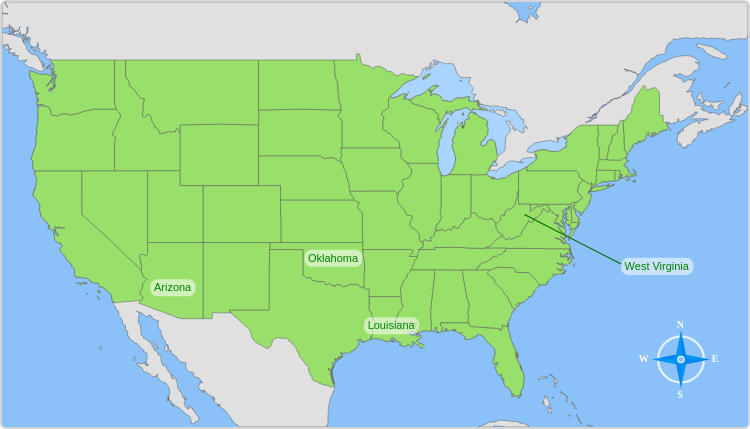

In [3]:

import json
from IPython.display import display, Image as IPImage

with open("data/scienceqa/train.json") as f:
    data = json.load(f)

sample = data[0]
print("Sample ID:", sample["id"])
print("\nImage:", sample["image"])
print("\nQuestion:", sample["conversations"][0]["value"][:300])
print("\nAnswer:", sample["conversations"][1]["value"][:200])

# Show the image
try:
    display(IPImage(filename=sample["image"], width=300))
except:
    print("(Image display not available in this environment)")


In [1]:
import os, sys, json, torch, re, time
from tqdm.notebook import tqdm
from PIL import Image

sys.path.insert(0, "LLaVA")

MODEL = "liuhaotian/llava-v1.5-7b"
TEST_DATA = "data/scienceqa/test.json"
MAX_EVAL = 200
TEXT_ONLY_SAMPLES = 100
MAX_NEW_TOKENS = 256
ANSWER_INSTRUCTION = "\nAnswer with the option letter only (A, B, C, D, or E)."
os.makedirs("results", exist_ok=True)

def extract_answer(text):
    if not text: return None
    text = text.strip()
    for pat in [r'\(([A-E])\)', r'answer\s+is\s+\(?([A-E])\)?',
                r'(?:choice|option|answer)[:\s]+\(?([A-E])\)?', r'\*\*([A-E])\*\*']:
        m = re.search(pat, text, re.IGNORECASE)
        if m: return m.group(1).upper()
    m = re.match(r'^([A-E])[.\s:]', text, re.IGNORECASE)
    if m: return m.group(1).upper()
    m = re.match(r'^([A-E])$', text.strip(), re.IGNORECASE)
    if m: return m.group(1).upper()
    m = re.search(r'\b([A-E])\b', text, re.IGNORECASE)
    if m: return m.group(1).upper()
    return None

print("Loading LLaVA-1.5-7B...")
from llava.model.builder import load_pretrained_model
from llava.mm_utils import tokenizer_image_token, process_images, get_model_name_from_path
from llava.constants import IMAGE_TOKEN_INDEX
from llava.conversation import conv_templates

# builder auto-sets torch_dtype=float16 when load_4bit=False — do NOT pass torch_dtype
tokenizer, model, image_processor, _ = load_pretrained_model(
    MODEL, None, get_model_name_from_path(MODEL),
    load_4bit=False, device_map="cuda:0"
)
model.eval()
torch.cuda.empty_cache()
print(f"Model loaded - VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB")

with open(TEST_DATA) as f:
    test_data = json.load(f)[:MAX_EVAL]
print(f"Evaluating {len(test_data)} samples...")

# ---- WITH IMAGES ----
print("\n--- Evaluating WITH images ---")
start = time.time()
correct, total = 0, 0
predictions = []

for item in tqdm(test_data, desc="With image"):
    gt = extract_answer(item["conversations"][1]["value"])
    if gt is None: continue
    try:
        img = Image.open(item["image"]).convert("RGB")
        img_t = process_images([img], image_processor, model.config)
        if isinstance(img_t, list): img_t = img_t[0]
        if img_t.dim() == 3: img_t = img_t.unsqueeze(0)
        img_t = img_t.to(model.device, dtype=torch.float16)
    except: continue

    question = item["conversations"][0]["value"] + ANSWER_INSTRUCTION
    conv = conv_templates["vicuna_v1"].copy()
    conv.append_message(conv.roles[0], question)
    conv.append_message(conv.roles[1], None)
    ids = tokenizer_image_token(
        conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
    ).unsqueeze(0).to(model.device)

    with torch.no_grad():
        out = model.generate(ids, images=img_t, do_sample=False,
                             max_new_tokens=MAX_NEW_TOKENS, use_cache=True)
    # LLaVA always uses inputs_embeds — output is generated tokens only, no slicing
    resp = tokenizer.decode(out[0], skip_special_tokens=True).strip()
    pred = extract_answer(resp)
    ok = (pred == gt)
    correct += int(ok)
    total += 1
    predictions.append({"id": item["id"], "gt": gt, "pred": pred,
                        "correct": ok, "response": resp[:300]})
    if total <= 3:
        print(f"\n[DEBUG {total}] GT={gt} | Pred={pred} | Raw={repr(resp[:100])}")
    if total % 50 == 0: torch.cuda.empty_cache()

acc_img = correct / total * 100 if total > 0 else 0
print(f"\nWith Image: {acc_img:.1f}% ({correct}/{total})")

# ---- TEXT ONLY ----
print("\n--- Evaluating TEXT ONLY ---")
t_correct, t_total = 0, 0
for item in tqdm(test_data[:TEXT_ONLY_SAMPLES], desc="Text only"):
    gt = extract_answer(item["conversations"][1]["value"])
    if gt is None: continue
    q = item["conversations"][0]["value"].replace("<image>\n","").replace("<image>","") + ANSWER_INSTRUCTION
    conv = conv_templates["vicuna_v1"].copy()
    conv.append_message(conv.roles[0], q)
    conv.append_message(conv.roles[1], None)
    ids = tokenizer(conv.get_prompt(), return_tensors='pt').input_ids.to(model.device)
    with torch.no_grad():
        out = model.generate(ids, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
    # LLaVA always uses inputs_embeds — no slicing
    resp = tokenizer.decode(out[0], skip_special_tokens=True).strip()
    t_correct += int(extract_answer(resp) == gt)
    t_total += 1

acc_text = t_correct / t_total * 100 if t_total > 0 else 0
elapsed = (time.time() - start) / 60

print("\n" + "="*55)
print("   ZERO-SHOT RESULTS")
print("="*55)
print(f"  With Image:  {acc_img:.1f}%  ({correct}/{total})")
print(f"  Text Only:   {acc_text:.1f}%  ({t_correct}/{t_total})")
print(f"  Visual Gap:  {acc_img - acc_text:.1f}%")
print(f"  Time:        {elapsed:.1f} min")
print("="*55)

metrics = {"model": "LLaVA-1.5-7B (zero-shot, float16)",
           "accuracy_with_image": round(acc_img, 2),
           "accuracy_text_only": round(acc_text, 2),
           "visual_grounding_gap": round(acc_img - acc_text, 2),
           "samples_with_image": total, "samples_text_only": t_total}
with open("results/zeroshot_metrics.json", 'w') as f: json.dump(metrics, f, indent=2)
with open("results/zeroshot_predictions.json", 'w') as f:
    json.dump(predictions, f, indent=2, ensure_ascii=False)
errors = [p for p in predictions if not p["correct"]]
with open("results/zeroshot_errors.json", 'w') as f:
    json.dump(errors[:30], f, indent=2, ensure_ascii=False)
print("\nResults saved to results/")


Loading LLaVA-1.5-7B...


W0509 11:45:41.153000 16676 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded - VRAM: 14.2 GB
Evaluating 200 samples...

--- Evaluating WITH images ---


With image:   0%|          | 0/200 [00:00<?, ?it/s]


[DEBUG 1] GT=B | Pred=A | Raw='A'

[DEBUG 2] GT=B | Pred=B | Raw='B'

[DEBUG 3] GT=B | Pred=B | Raw='B'

With Image: 63.5% (127/200)

--- Evaluating TEXT ONLY ---


Text only:   0%|          | 0/100 [00:00<?, ?it/s]


   ZERO-SHOT RESULTS
  With Image:  63.5%  (127/200)
  Text Only:   56.0%  (56/100)
  Visual Gap:  7.5%
  Time:        0.8 min

Results saved to results/


In [2]:
import json, os

with open("results/zeroshot_metrics.json") as f:
    m = json.load(f)

print("=" * 51)
print(f"  Setting           | Accuracy")
print(f"  ------------------|----------")
print(f"  With Image        | {m['accuracy_with_image']:5.1f}%")
print(f"  Text Only         | {m['accuracy_text_only']:5.1f}%")
print(f"  Visual Gap        | {m['visual_grounding_gap']:5.1f}%")
print("=" * 51)


  Setting           | Accuracy
  ------------------|----------
  With Image        |  63.5%
  Text Only         |  56.0%
  Visual Gap        |   7.5%


In [3]:
import json

with open("results/zeroshot_errors.json") as f:
    errors = json.load(f)

print(f"Total errors saved: {len(errors)}")
print()
for i, e in enumerate(errors[:5]):
    print(f"--- Error {i+1} ---")
    print(f"  GT: {e['gt']} | Pred: {e['pred']}")
    print(f"  Response: {e['response'][:200]}")
    print()



Total errors saved: 30

--- Error 1 ---
  GT: B | Pred: A
  Response: A

--- Error 2 ---
  GT: B | Pred: D
  Response: D

--- Error 3 ---
  GT: C | Pred: A
  Response: A

--- Error 4 ---
  GT: C | Pred: A
  Response: A

--- Error 5 ---
  GT: B | Pred: A
  Response: A



In [5]:
import os, sys, json, torch
import transformers
from torch.utils.data import Dataset
from PIL import Image

sys.path.insert(0, "LLaVA")

MODEL_NAME   = "liuhaotian/llava-v1.5-7b"
TRAIN_DATA   = "data/scienceqa/train.json"
OUTPUT_DIR   = "checkpoints/llava-scienceqa-baseline"
MAX_TRAIN_SAMPLES = 2000   # limits VRAM; use None for all 6218
BATCH_SIZE   = 1
GRAD_ACCUM   = 16
MAX_LENGTH   = 512         # shorter than 1024 to save VRAM
NUM_EPOCHS   = 1
LEARNING_RATE = 2e-5
LORA_R       = 8
LORA_ALPHA   = 16

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Loading LLaVA-1.5-7B (fp16, no quantization)...")
from llava.model.builder import load_pretrained_model
from llava.mm_utils import tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, IGNORE_INDEX
from llava.conversation import conv_templates

# load_4bit=False → builder sets torch_dtype=float16 automatically
tokenizer, model, image_processor, _ = load_pretrained_model(
    MODEL_NAME, None, "llava-v1.5-7b", load_4bit=False, device_map="cuda:0"
)
print(f"  Params: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
print(f"  VRAM after load: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

# Required for gradient checkpointing + LoRA on frozen backbone
model.enable_input_require_grads()

print("Applying LoRA...")
from peft import LoraConfig, get_peft_model

targets = set()
for name, module in model.named_modules():
    if any(kw in name for kw in ['mm_projector', 'vision_tower', 'vision_resampler']):
        continue
    if isinstance(module, torch.nn.Linear):
        targets.add(name.split('.')[-1])
targets.discard('lm_head')
targets = list(targets)

model = get_peft_model(model, LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA,
    target_modules=targets, lora_dropout=0.05,
    bias="none", task_type="CAUSAL_LM",
))
model.print_trainable_parameters()

class ScienceQADataset(Dataset):
    def __init__(self, path, tok, proc, max_len, max_samples=None):
        with open(path) as f:
            data = json.load(f)
        self.data = data[:max_samples] if max_samples else data
        self.tok = tok
        self.proc = proc
        self.max_len = max_len
        print(f"  Loaded {len(self.data)} training samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        try:
            img = Image.open(item["image"]).convert("RGB")
            img_t = self.proc.preprocess(img, return_tensors='pt')['pixel_values'][0]
        except:
            img_t = torch.zeros(3, 336, 336)

        human = item["conversations"][0]["value"]
        gpt   = item["conversations"][1]["value"]
        conv  = conv_templates["vicuna_v1"].copy()
        conv.append_message(conv.roles[0], human)
        conv.append_message(conv.roles[1], gpt)
        prompt = conv.get_prompt()

        ids = tokenizer_image_token(prompt, self.tok, IMAGE_TOKEN_INDEX, return_tensors='pt')
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]

        labels = ids.clone()
        sep = "ASSISTANT: "
        prompt_part = prompt.split(sep)[0] + sep
        prompt_ids = tokenizer_image_token(prompt_part, self.tok, IMAGE_TOKEN_INDEX, return_tensors='pt')
        labels[:len(prompt_ids)] = IGNORE_INDEX

        return {"input_ids": ids, "labels": labels, "images": img_t}

class Collator:
    def __init__(self, tok, max_len):
        self.tok = tok
        self.max_len = max_len

    def __call__(self, batch):
        ids  = [b["input_ids"] for b in batch]
        labs = [b["labels"]    for b in batch]
        imgs = [b["images"]    for b in batch]
        pad_id = self.tok.pad_token_id or 0
        ids  = torch.nn.utils.rnn.pad_sequence(ids,  batch_first=True, padding_value=pad_id)
        labs = torch.nn.utils.rnn.pad_sequence(labs, batch_first=True, padding_value=IGNORE_INDEX)
        ids  = ids[:, :self.max_len]
        labs = labs[:, :self.max_len]
        return {"input_ids": ids, "labels": labs,
                "images": torch.stack(imgs), "attention_mask": ids.ne(pad_id)}

train_ds = ScienceQADataset(TRAIN_DATA, tokenizer, image_processor, MAX_LENGTH, MAX_TRAIN_SAMPLES)

print(f"\nStarting training...")
print(f"  Samples: {len(train_ds)} | Batch: {BATCH_SIZE}x{GRAD_ACCUM}={BATCH_SIZE*GRAD_ACCUM}")
print(f"  Steps: ~{len(train_ds) // (BATCH_SIZE * GRAD_ACCUM)}")
torch.cuda.empty_cache()

trainer = transformers.Trainer(
    model=model,
    args=transformers.TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        warmup_ratio=0.03,
        lr_scheduler_type="cosine",
        logging_steps=5,
        save_steps=200,
        save_total_limit=2,
        fp16=True,
        gradient_checkpointing=True,
        dataloader_num_workers=0,
        remove_unused_columns=False,
        report_to="none",
        max_grad_norm=1.0,
        optim="adamw_torch",
        dataloader_pin_memory=False,
    ),
    train_dataset=train_ds,
    data_collator=Collator(tokenizer, MAX_LENGTH),
    tokenizer=tokenizer,
)

trainer.train()
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nModel saved to {OUTPUT_DIR}")



Loading LLaVA-1.5-7B (fp16, no quantization)...


You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Params: 7063M
  VRAM after load: 14.2 GB
Applying LoRA...
trainable params: 21,168,128 || all params: 7,084,070,912 || trainable%: 0.2988
  Loaded 2000 training samples

Starting training...
  Samples: 2000 | Batch: 1x16=16
  Steps: ~125


c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\accelerate\accelerator.py:427: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\accelerate\accelerator.py:1301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  new_forward = torch.cuda.amp.autocast(dtype=torch.float16)(model_forward_func)


  0%|          | 0/125 [00:00<?, ?it/s]

c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\torch\_dynamo\eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\torch\utils\checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


{'loss': 1.4617, 'learning_rate': 1.9996629653035128e-05, 'epoch': 0.04}
{'loss': 1.3391, 'learning_rate': 1.9878905881817254e-05, 'epoch': 0.08}
{'loss': 1.3039, 'learning_rate': 1.9594929736144978e-05, 'epoch': 0.12}
{'loss': 1.1375, 'learning_rate': 1.9149480258259535e-05, 'epoch': 0.16}
{'loss': 0.9516, 'learning_rate': 1.8550053929480202e-05, 'epoch': 0.2}
{'loss': 0.9219, 'learning_rate': 1.780673851171728e-05, 'epoch': 0.24}
{'loss': 0.8609, 'learning_rate': 1.6932043280253892e-05, 'epoch': 0.28}
{'loss': 0.8055, 'learning_rate': 1.5940688504813664e-05, 'epoch': 0.32}
{'loss': 0.6891, 'learning_rate': 1.4849357721743169e-05, 'epoch': 0.36}
{'loss': 0.8617, 'learning_rate': 1.3676416966327201e-05, 'epoch': 0.4}
{'loss': 0.7926, 'learning_rate': 1.2441605690283915e-05, 'epoch': 0.44}
{'loss': 0.8039, 'learning_rate': 1.1165704565997593e-05, 'epoch': 0.48}
{'loss': 0.6961, 'learning_rate': 9.870185768020694e-06, 'epoch': 0.52}
{'loss': 0.7246, 'learning_rate': 8.576851617267151e-06

c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.



Model saved to checkpoints/llava-scienceqa-baseline


In [7]:
import sys, os
sys.path.insert(0, "LLaVA")

OUTPUT_DIR = "checkpoints/llava-scienceqa-baseline"

print("Files in checkpoint:", os.listdir(OUTPUT_DIR))

# Copy base model config into the LoRA checkpoint directory
from llava.model.language_model.llava_llama import LlavaConfig
config = LlavaConfig.from_pretrained("liuhaotian/llava-v1.5-7b")
config.save_pretrained(OUTPUT_DIR)
print("config.json saved — now re-run the fine-tuned eval cell")


Files in checkpoint: ['adapter_config.json', 'adapter_model.safetensors', 'README.md', 'special_tokens_map.json', 'tokenizer.model', 'tokenizer_config.json']


You are using a model of type llava to instantiate a model of type llava_llama. This is not supported for all configurations of models and can yield errors.
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 4096}


config.json saved — now re-run the fine-tuned eval cell


In [1]:
import os, sys, json, torch, re, time, gc
from tqdm.notebook import tqdm
from PIL import Image

sys.path.insert(0, "LLaVA")

CHECKPOINT = r"c:\Users\24280078\Documents\dvlm project\checkpoints\llava-scienceqa-baseline"
BASE_MODEL  = "liuhaotian/llava-v1.5-7b"
TEST_DATA   = "data/scienceqa/test.json"
MAX_EVAL    = 500
TEXT_ONLY_N = 200
ANSWER_INSTRUCTION = "\nAnswer with the option letter only (A, B, C, D, or E)."

def extract_answer(text):
    if not text: return None
    text = text.strip()
    for pat in [r'\(([A-E])\)', r'answer\s+is\s+\(?([A-E])\)?',
                r'(?:choice|option|answer)[:\s]+\(?([A-E])\)?', r'\*\*([A-E])\*\*']:
        m = re.search(pat, text, re.IGNORECASE)
        if m: return m.group(1).upper()
    m = re.match(r'^([A-E])[.\s:]', text, re.IGNORECASE)
    if m: return m.group(1).upper()
    m = re.match(r'^([A-E])$', text.strip(), re.IGNORECASE)
    if m: return m.group(1).upper()
    m = re.search(r'\b([A-E])\b', text, re.IGNORECASE)
    if m: return m.group(1).upper()
    return None

if not os.path.exists(CHECKPOINT):
    print("No checkpoint found — run training cell first.")
else:
    # Free ALL training objects from VRAM — trainer holds a reference too
    for _var in ['trainer', 'model', 'train_ds']:
        if _var in dir(__builtins__) or _var in globals():
            try: exec(f'del {_var}')
            except: pass
    # Also clear via globals directly
    for _var in ['trainer', 'model', 'train_ds']:
        globals().pop(_var, None)
    gc.collect()
    torch.cuda.empty_cache()
    free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
    print(f"VRAM available after cleanup: {free:.1f} GB")
    if free < 13:
        print("WARNING: Less than 13 GB free — may OOM. Consider restarting kernel and running only this cell.")

    # Ensure required files exist in checkpoint
    nlt = os.path.join(CHECKPOINT, 'non_lora_trainables.bin')
    if not os.path.exists(nlt):
        torch.save({}, nlt)
        print("Created non_lora_trainables.bin")

    cfg_path = os.path.join(CHECKPOINT, 'config.json')
    if not os.path.exists(cfg_path):
        from llava.model.language_model.llava_llama import LlavaConfig
        LlavaConfig.from_pretrained(BASE_MODEL).save_pretrained(CHECKPOINT)
        print("Saved config.json")

    from llava.model.builder import load_pretrained_model
    from llava.mm_utils import tokenizer_image_token, process_images
    from llava.constants import IMAGE_TOKEN_INDEX
    from llava.conversation import conv_templates

    print("\nLoading fine-tuned model...")
    tokenizer, model, image_processor, _ = load_pretrained_model(
        CHECKPOINT, BASE_MODEL, "llava-v1.5-7b-lora",
        load_4bit=False, device_map="cuda:0"
    )
    model.eval()
    torch.cuda.empty_cache()
    print(f"Model loaded. VRAM: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

    with open(TEST_DATA) as f:
        test_data = json.load(f)[:MAX_EVAL]

    # ---- WITH IMAGES ----
    print(f"\nEvaluating {len(test_data)} samples WITH images...")
    correct, total = 0, 0
    preds = []

    for item in tqdm(test_data, desc="Fine-tuned eval"):
        gt = extract_answer(item["conversations"][1]["value"])
        if not gt: continue
        try:
            img = Image.open(item["image"]).convert("RGB")
            img_t = process_images([img], image_processor, model.config)
            if isinstance(img_t, list): img_t = img_t[0]
            if img_t.dim() == 3: img_t = img_t.unsqueeze(0)
            img_t = img_t.to(model.device, dtype=torch.float16)
        except: continue

        question = item["conversations"][0]["value"] + ANSWER_INSTRUCTION
        conv = conv_templates["vicuna_v1"].copy()
        conv.append_message(conv.roles[0], question)
        conv.append_message(conv.roles[1], None)
        ids = tokenizer_image_token(
            conv.get_prompt(), tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt'
        ).unsqueeze(0).to(model.device)

        with torch.no_grad():
            out = model.generate(ids, images=img_t, do_sample=False, max_new_tokens=256)
        resp = tokenizer.decode(out[0], skip_special_tokens=True).strip()
        pred = extract_answer(resp)
        ok = pred == gt
        correct += int(ok)
        total += 1
        preds.append({"id": item["id"], "gt": gt, "pred": pred,
                      "correct": ok, "response": resp[:300]})
        if total % 50 == 0: torch.cuda.empty_cache()

    acc = correct / total * 100 if total > 0 else 0

    # ---- TEXT ONLY ----
    print(f"\nText-only probe ({TEXT_ONLY_N} samples)...")
    tc, tt = 0, 0
    for item in tqdm(test_data[:TEXT_ONLY_N], desc="Text only"):
        gt = extract_answer(item["conversations"][1]["value"])
        if not gt: continue
        q = item["conversations"][0]["value"].replace("<image>\n","").replace("<image>","") + ANSWER_INSTRUCTION
        conv = conv_templates["vicuna_v1"].copy()
        conv.append_message(conv.roles[0], q)
        conv.append_message(conv.roles[1], None)
        ids = tokenizer(conv.get_prompt(), return_tensors='pt').input_ids.to(model.device)
        with torch.no_grad():
            out = model.generate(ids, do_sample=False, max_new_tokens=256)
        resp = tokenizer.decode(out[0], skip_special_tokens=True).strip()
        tc += int(extract_answer(resp) == gt)
        tt += 1

    acc_t = tc / tt * 100 if tt > 0 else 0
    zs_acc = None
    if os.path.exists("results/zeroshot_metrics.json"):
        with open("results/zeroshot_metrics.json") as f:
            zs_acc = json.load(f).get("accuracy_with_image")

    print("\n" + "="*55)
    print("   FINAL RESULTS")
    print("="*55)
    print(f"  Fine-tuned (image):  {acc:.1f}%")
    print(f"  Fine-tuned (text):   {acc_t:.1f}%")
    print(f"  Visual gap:          {acc - acc_t:.1f}%")
    if zs_acc:
        print(f"  Zero-shot (image):   {zs_acc:.1f}%")
        print(f"  Improvement:         +{acc - zs_acc:.1f}%")
    print("="*55)

    metrics = {"accuracy_finetuned": round(acc, 2), "accuracy_text_only": round(acc_t, 2),
               "visual_gap": round(acc - acc_t, 2), "zero_shot_accuracy": zs_acc,
               "improvement": round(acc - zs_acc, 2) if zs_acc else None}
    with open("results/finetuned_metrics.json", 'w') as f: json.dump(metrics, f, indent=2)
    errors = [p for p in preds if not p["correct"]]
    with open("results/finetuned_errors.json", 'w') as f:
        json.dump(errors[:50], f, indent=2, ensure_ascii=False)
    print("\nSaved to results/")



VRAM available after cleanup: 17.1 GB


W0509 15:19:14.523000 3240 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
c:\Users\24280078\AppData\Local\anaconda3\envs\llm_align\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Loading fine-tuned model...
Loading LLaVA from base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading additional LLaVA weights...
Loading LoRA weights...
Merging LoRA weights...
Model is loaded...
Model loaded. VRAM: 14.2 GB

Evaluating 500 samples WITH images...


Fine-tuned eval:   0%|          | 0/500 [00:00<?, ?it/s]


Text-only probe (200 samples)...


Text only:   0%|          | 0/200 [00:00<?, ?it/s]


   FINAL RESULTS
  Fine-tuned (image):  62.6%
  Fine-tuned (text):   51.0%
  Visual gap:          11.6%
  Zero-shot (image):   63.5%
  Improvement:         +-0.9%

Saved to results/


In [2]:
import json, os

print("=" * 65)
print(f"  {'Model':<22} | {'Image Acc':>9} | {'Text Acc':>8} | {'Gap':>6}")
print(f"  {'-'*22}-+-{'-'*9}-+-{'-'*8}-+-{'-'*6}")

if os.path.exists("results/zeroshot_metrics.json"):
    with open("results/zeroshot_metrics.json") as f:
        zs = json.load(f)
    print(f"  {'LLaVA-1.5-7B (0-shot)':<22} | {zs['accuracy_with_image']:>8.1f}% | {zs['accuracy_text_only']:>7.1f}% | {zs['visual_grounding_gap']:>5.1f}%")

if os.path.exists("results/finetuned_metrics.json"):
    with open("results/finetuned_metrics.json") as f:
        ft = json.load(f)
    print(f"  {'LLaVA-1.5-7B (QLoRA)':<22} | {ft['accuracy_finetuned']:>8.1f}% | {ft['accuracy_text_only']:>7.1f}% | {ft['visual_gap']:>5.1f}%")
    if ft.get("improvement"):
        print(f"  {'Improvement':<22} | {ft['improvement']:>+8.1f}% |          |")

print("=" * 65)
print("\nFiles in results/:")
for f in ["zeroshot_metrics.json","zeroshot_errors.json","finetuned_metrics.json","finetuned_errors.json"]:
    if os.path.exists(f"results/{f}"):
        print(f"  + {f}")


  Model                  | Image Acc | Text Acc |    Gap
  -----------------------+-----------+----------+-------
  LLaVA-1.5-7B (0-shot)  |     63.5% |    56.0% |   7.5%
  LLaVA-1.5-7B (QLoRA)   |     62.6% |    51.0% |  11.6%
  Improvement            |     -0.9% |          |

Files in results/:
  + zeroshot_metrics.json
  + zeroshot_errors.json
  + finetuned_metrics.json
  + finetuned_errors.json


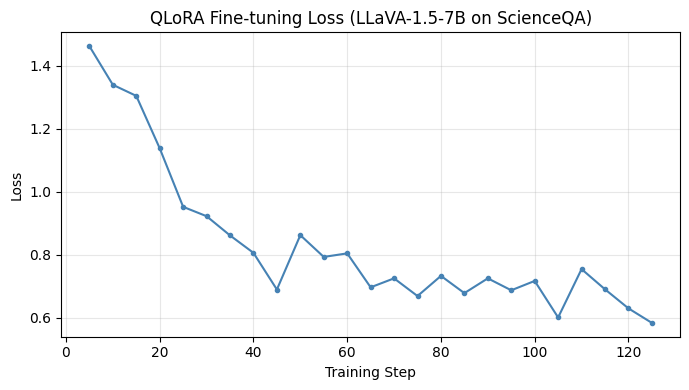

Saved to figures/training_loss.pdf


In [3]:
import matplotlib.pyplot as plt
import os

steps  = [5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100,105,110,115,120,125]
losses = [1.4617,1.3391,1.3039,1.1375,0.9516,0.9219,0.8609,0.8055,0.6891,0.8617,
          0.7926,0.8039,0.6961,0.7246,0.6684,0.7324,0.6777,0.7246,0.6867,0.7164,
          0.6004,0.7539,0.6898,0.6293,0.5832]

os.makedirs("figures", exist_ok=True)
plt.figure(figsize=(7, 4))
plt.plot(steps, losses, marker='o', markersize=3, linewidth=1.5, color='steelblue')
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("QLoRA Fine-tuning Loss (LLaVA-1.5-7B on ScienceQA)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/training_loss.pdf", bbox_inches='tight')
plt.savefig("figures/training_loss.png", bbox_inches='tight')
plt.show()
print("Saved to figures/training_loss.pdf")


In [5]:
import json

with open("results/zeroshot_errors.json") as f:
    errors = json.load(f)
with open("data/scienceqa/test.json") as f:
    test_lookup = {item["id"]: item for item in json.load(f)}

for i, e in enumerate(errors[:5]):
    item = test_lookup.get(e["id"], {})
    q = item["conversations"][0]["value"].replace("<image>\n","").replace("<image>","")
    q = q.split("\n")[0][:80]  # just first line, truncated
    print(f"Error {i+1}: GT={e['gt']} | Pred={e['pred']} | Q: {q}")


Error 1: GT=B | Pred=A | Q: Context: People can use the engineering-design process to develop solutions to p
Error 2: GT=B | Pred=D | Q: Context: This passage describes the fleece type trait in sheep:
Error 3: GT=C | Pred=A | Q: Context: Select the best answer.
Error 4: GT=C | Pred=A | Q: Context: The images below show two pairs of magnets. The magnets in different pa
Error 5: GT=B | Pred=A | Q: Context: Use the data to answer the question below.


In [4]:
import json

with open("results/zeroshot_errors.json") as f:
    errors = json.load(f)

for i, e in enumerate(errors[:5]):
    print(f"Error {i+1}: GT={e['gt']} | Pred={e['pred']} | Response: {e['response'][:100]}")


Error 1: GT=B | Pred=A | Response: A
Error 2: GT=B | Pred=D | Response: D
Error 3: GT=C | Pred=A | Response: A
Error 4: GT=C | Pred=A | Response: A
Error 5: GT=B | Pred=A | Response: A
